# Decompose the CO₂ levers of action into sub-levers

AeroMAPS expresses the reduction of CO₂ emissions with respect to a frozen-technology trajectory as a cascade of levers of action: demand, aircraft efficiency, operations and load factor, aircraft energy, and carbon offsetting. The `air_transport_co2_emissions` plot draws them as wedges.

This tutorial shows how to split some of these wedges into sub-wedges:

- the **aircraft efficiency** wedge per aircraft of the fleet (bottom-up fleet model),
- the **fleet operations** wedge per operational concept (generic operations module),
- the **aircraft energy** wedge per energy pathway (generic energy models),
- the **carbon offset** wedge per offsetting scheme (generic offsets module),
- **every** wedge per market.

Each decomposition is exact by construction: the sub-wedges, including an explicit residual, sum to the wedge they split.

The scenario is the one of the fleet tutorial (default markets, fleet and energy carriers), with two additions. The recent reference aircraft improve by 10 % between 2020 and 2050 through the `continuous_improvement_factor_energy` field of `data/aircraft_inventory.yaml`, so that the corresponding sub-wedge is visible. The generic operations module is activated with the `models.operations` key of `data/config.yaml`, which replaces the single logistic operations gain by the default operational concepts. The generic offsets module is activated with the `models.offsets` key, which replaces the simple offset models by the two illustrative schemes of the default file: a CORSIA-like scheme offsetting the emissions above a baseline, and a removals obligation growing to cover all the remaining emissions in 2050.

## Load and compute

The decomposition models `DetailedCo2EmissionsPerAircraft`, `DetailedCo2EmissionsPerPathway` and `DetailedCo2EmissionsPerMarket` are registered with the bottom-up efficiency and generic energy standards. `DetailedCo2EmissionsPerOperationalConcept` comes with the generic operations module, and `OffsetsUseChoice` with the generic offsets module.

In [1]:
from aeromaps import create_process

process = create_process(configuration_file="data/config.yaml")
process.compute()
process.write_json()

## The aggregated wedges

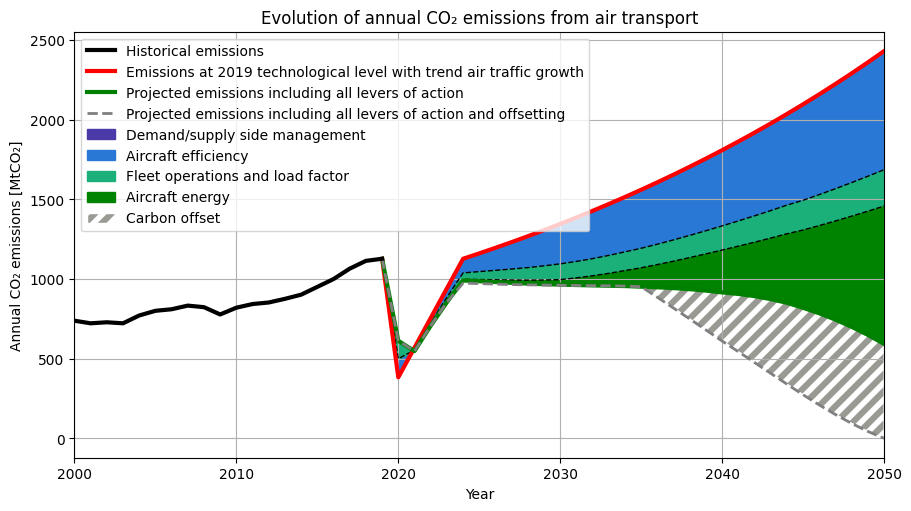

In [2]:
process.plot("air_transport_co2_emissions", save=False)

## Efficiency per aircraft, operations per concept, energy per pathway

`air_transport_co2_emissions_detailed` replaces the efficiency, operations and energy wedges by their sub-wedges. When a decomposition is not available (top-down fleet, or non-generic energy models), the corresponding wedge falls back to a single band.

Efficiency sub-wedges (`DetailedCo2EmissionsPerAircraft`):

- **Fleet renewal**: replacement of the old reference aircraft by the recent one, without any new aircraft.
- **Continuous improvement**: drift of the recent reference aircraft itself when a `continuous_improvement_factor_energy` is set.
- **One band per new aircraft**: its additional gain beyond fleet renewal, weighted by the share of the market it serves.
- **Freight fleet**: the freight efficiency, which has no bottom-up fleet.
- **Traffic mix**: the effect of the changing split of ASK between markets. It can be negative when the most energy-intensive markets grow faster.

Operations sub-wedges (`DetailedCo2EmissionsPerOperationalConcept`): the default concepts are the three blocks of the DESTINATION 2050 roadmap (2025 edition), airline operations, airspace and ATM, airports and ground operations, whose fuel burn reductions add up to 7.8 % in 2030 and 11.6 % in 2050 in the roadmap. Concepts compose multiplicatively, which gives 11.1 % in 2050, and the wedge is shared between them in logarithmic proportion, so the sub-wedges do not depend on the declaration order and sum exactly to the wedge. The load factor then gets its own band.

Energy sub-wedges (`DetailedCo2EmissionsPerPathway`): each pathway is credited with its energy consumption times the gap between the reference-year mean carbon intensity and its own. The reference is the mean carbon intensity of the reference year, not that of fossil kerosene. Here they coincide, so fossil kerosene has no band; in a scenario where low-carbon fuels are already used in the reference year, fossil kerosene shows a small negative band as long as some of it remains.

Offset sub-wedges (generic offsets module): one hatched band per offsetting scheme. The carbon offset is the plain sum of the scheme quantities, so there is no residual band.

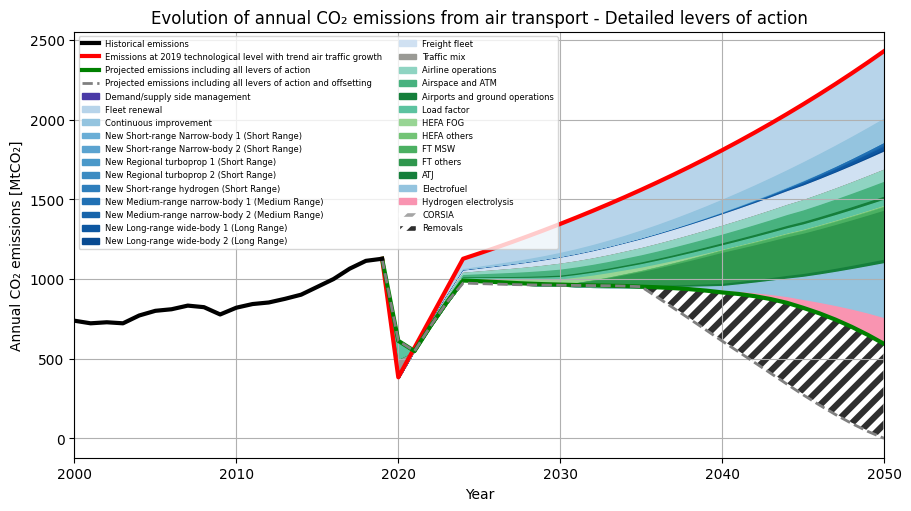

In [3]:
process.plot("air_transport_co2_emissions_detailed", save=False)

### Coarser granularity

The same plot accepts `efficiency_granularity="category"` (one band per fleet category) and `energy_granularity="family"` (biofuels, electrofuels, fossil-derived, hydrogen, electric). A third keyword, `offset_granularity="category"`, groups the offsetting schemes per category. `air_transport_co2_emissions_grouped` is the shortcut for the three.

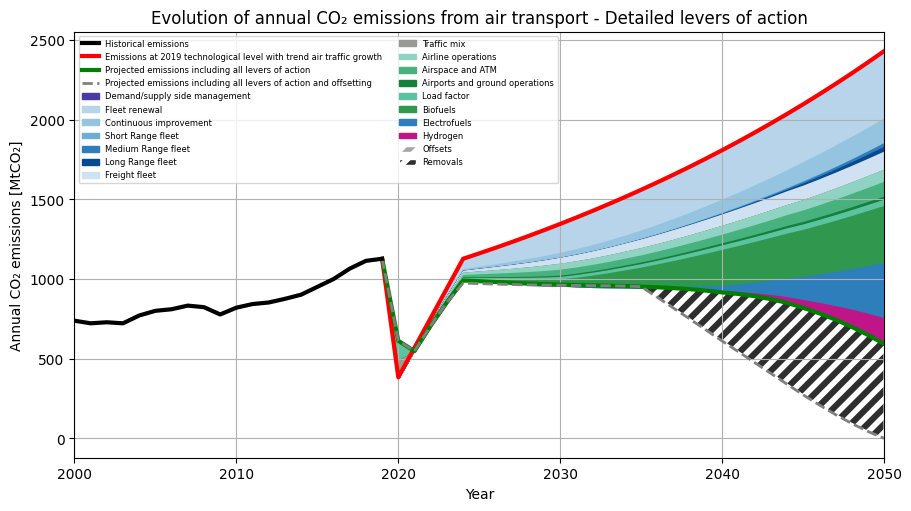

In [4]:
process.plot("air_transport_co2_emissions_grouped", save=False)

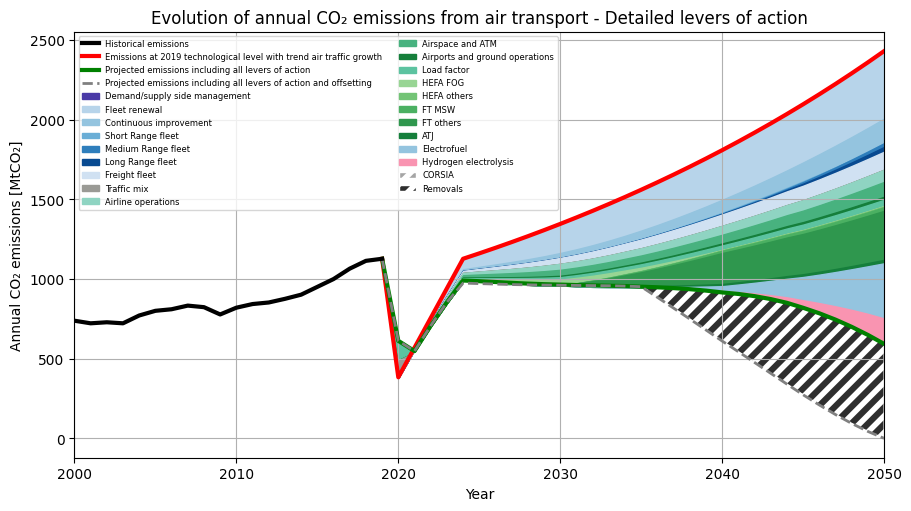

In [5]:
process.plot(
    "air_transport_co2_emissions_detailed",
    save=False,
    efficiency_granularity="category",
    energy_granularity="pathway",
)

## Every wedge per market

`DetailedCo2EmissionsPerMarket` recomputes the cascade, from the demand lever to the energy lever, for each passenger and freight market with its own traffic and energy intensities. It only needs the per-market intensities, so it is available with the top-down efficiency models too. The global cascade uses fleet-wide means, so the sum over markets differs from the global wedge by a cross-market-mix term, which is reported explicitly. Several per-market contributions change sign over time, so the plot uses one panel per lever with signed lines rather than a stacked chart.

The demand panel is empty here: the traffic of this scenario follows its baseline growth, so the demand lever is zero for every market.

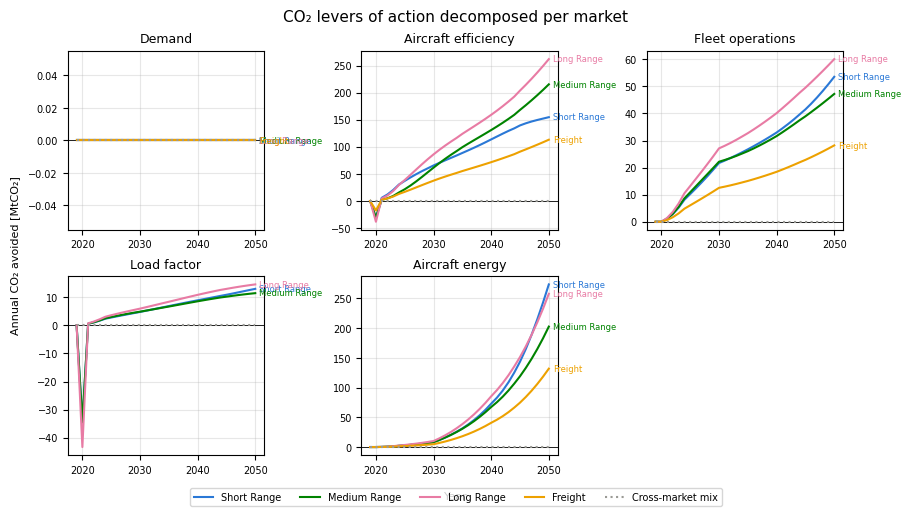

In [6]:
process.plot("air_transport_co2_emissions_per_market", save=False)

The per-market columns are exposed through a tidy accessor with a `(lever, market)` column index.

In [7]:
from aeromaps.models.impacts.emissions.co2_emissions import market_lever_dataframe

vector = process.data["vector_outputs"]
per_market = market_lever_dataframe(vector, process.markets)
per_market.loc[[2030, 2040, 2050]].round(1)

lever,demand,efficiency,operations,loadfactor,energy,demand,efficiency,operations,loadfactor,energy,demand,efficiency,operations,loadfactor,energy,demand,efficiency,operations,energy,demand,efficiency,operations,loadfactor,energy
market,short_range,short_range,short_range,short_range,short_range,medium_range,medium_range,medium_range,medium_range,medium_range,long_range,long_range,long_range,long_range,long_range,freight,freight,freight,freight,cross_mix,cross_mix,cross_mix,cross_mix,cross_mix
2030,0.0,65.6,21.7,4.8,8.1,0.0,61.6,22.2,4.9,8.3,0.0,86.1,27.1,5.9,10.1,0.0,37.5,12.5,4.8,0.0,0.0,0.0,0.0,0.0
2040,0.0,113.6,33.0,8.9,72.9,0.0,131.0,31.7,8.6,67.3,0.0,159.1,40.1,10.8,85.4,0.0,71.6,18.4,40.8,0.0,0.0,0.0,0.0,0.0
2050,0.0,154.7,53.6,13.0,273.6,0.0,215.3,47.2,11.4,202.6,0.0,261.9,60.1,14.6,257.7,0.0,113.1,28.2,131.8,0.0,0.0,0.0,0.0,0.0


In [8]:
per_market.xs("energy", level="lever", axis=1).loc[[2030, 2040, 2050]].round(1)

market,short_range,medium_range,long_range,freight,cross_mix
2030,8.1,8.3,10.1,4.8,0.0
2040,72.9,67.3,85.4,40.8,0.0
2050,273.6,202.6,257.7,131.8,0.0


## Sub-wedge values

The sub-wedges are ordinary output columns, in MtCO₂ avoided with respect to the frozen-technology trajectory. Helper functions of `co2_emissions.py` list the columns of each decomposition, so that no name has to be guessed.

In [9]:
from aeromaps.models.impacts.emissions.co2_emissions import (
    OPERATIONS_OTHER,
    aircraft_efficiency_sub_lever_columns,
    operations_concept_column,
    pathway_energy_sub_lever_columns,
)

efficiency_columns = aircraft_efficiency_sub_lever_columns(process.fleet_model.fleet)
energy_columns = pathway_energy_sub_lever_columns(process.pathways_manager)
operations_columns = [
    operations_concept_column(concept.name) for concept in process.operations_manager.get_all()
] + [operations_concept_column(OPERATIONS_OTHER)]

vector.loc[[2030, 2040, 2050], efficiency_columns].round(1).T

,2030,2040,2050
co2_emissions_lever_efficiency_fleet_renewal,182.6,311.6,424.2
co2_emissions_lever_efficiency_continuous_improvement,30.3,81.5,164.2
co2_emissions_lever_efficiency_freight,37.5,71.6,113.1
co2_emissions_lever_efficiency_other,0.0,0.0,0.0
co2_emissions_lever_efficiency_aircraft_short_range_new_short_range_narrow_body_1,0.0,2.5,6.0
co2_emissions_lever_efficiency_aircraft_short_range_new_short_range_narrow_body_2,0.0,0.0,3.5
co2_emissions_lever_efficiency_aircraft_short_range_new_regional_turboprop_1,0.3,4.9,12.8
co2_emissions_lever_efficiency_aircraft_short_range_new_regional_turboprop_2,0.0,0.0,3.4
co2_emissions_lever_efficiency_aircraft_short_range_new_short_range_hydrogen,0.0,-2.8,-35.6
co2_emissions_lever_efficiency_aircraft_medium_range_new_medium_range_narrow_body_1,0.0,2.7,14.7


In [10]:
vector.loc[[2030, 2040, 2050], energy_columns].round(1).T

,2030,2040,2050
co2_emissions_lever_energy_pathway_hefa_fog,36.7,1.5,2.4
co2_emissions_lever_energy_pathway_hefa_others,0.0,3.3,5.2
co2_emissions_lever_energy_pathway_ft_msw,0.0,14.3,22.5
co2_emissions_lever_energy_pathway_ft_others,0.0,194.5,308.0
co2_emissions_lever_energy_pathway_atj,0.0,13.6,21.5
co2_emissions_lever_energy_pathway_electrofuel,-5.4,31.7,346.1
co2_emissions_lever_energy_pathway_fossil_kerosene,0.0,0.0,0.0
co2_emissions_lever_energy_pathway_hydrogen_electrolysis,0.0,7.5,160.1
co2_emissions_lever_energy_pathway_hydrogen_gas,0.0,0.0,0.0
co2_emissions_lever_energy_pathway_hydrogen_gas_ccs,0.0,0.0,0.0


In [11]:
vector.loc[[2030, 2040, 2050], operations_columns].round(1).T

,2030,2040,2050
co2_emissions_lever_operations_concept_airline_operations,37.5,55.9,76.5
co2_emissions_lever_operations_concept_airspace_and_atm,37.5,54.6,93.3
co2_emissions_lever_operations_concept_airports_and_ground_operations,8.5,12.8,19.2
co2_emissions_lever_operations_concept_other,0.0,0.0,0.0


The per-concept gains themselves, in percentage points of the aggregate `operations_gain`, are available through the generic operations plots.

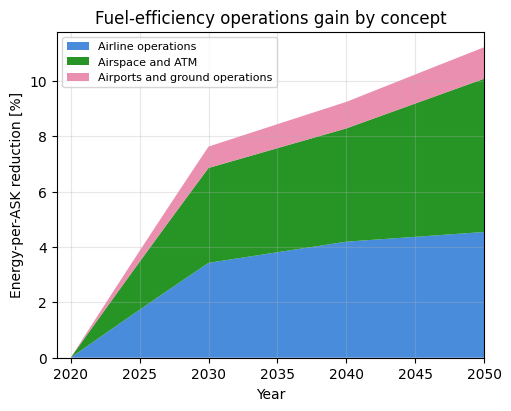

In [12]:
process.plot("operations_gain_by_concept", save=False)

`operations_gain_by_category` aggregates the concepts per operational category. A third plot, `operations_contrails_gain_by_concept`, splits the contrail climate-impact reduction; it is empty here because the default concepts carry no `contrails` channel.

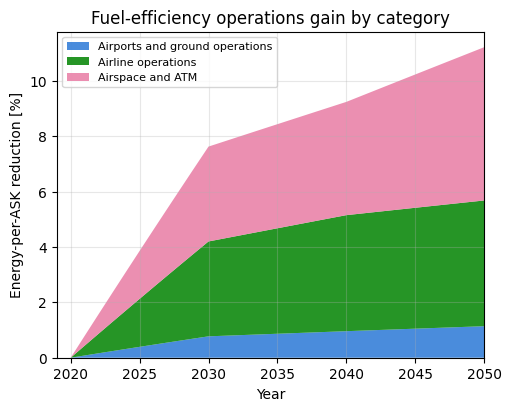

In [13]:
process.plot("operations_gain_by_category", save=False)

## Carbon offset per scheme

Each offsetting scheme has its own quantity rule and price. Its quantity is its sub-wedge, `co2_emissions_lever_offset_scheme_<scheme>`, and the price of the aggregate `carbon_offset` is the quantity-weighted mean of the scheme prices.

In [14]:
from aeromaps.models.impacts.emissions.co2_emissions import offset_scheme_column

schemes = [scheme.name for scheme in process.offsets_manager.get_all()]
offset_columns = [offset_scheme_column(scheme) for scheme in schemes]
price_columns = [f"{scheme}_carbon_offset_price" for scheme in schemes]
vector.loc[[2030, 2040, 2050], offset_columns + ["carbon_offset"] + price_columns + ["carbon_offset_price"]].round(1).T

,2030,2040,2050
co2_emissions_lever_offset_scheme_corsia,4.1,0.0,0.0
co2_emissions_lever_offset_scheme_removals,0.0,305.4,592.7
carbon_offset,4.1,305.4,592.7
corsia_carbon_offset_price,41.8,60.0,60.0
removals_carbon_offset_price,200.0,166.7,100.0
carbon_offset_price,41.8,166.7,100.0


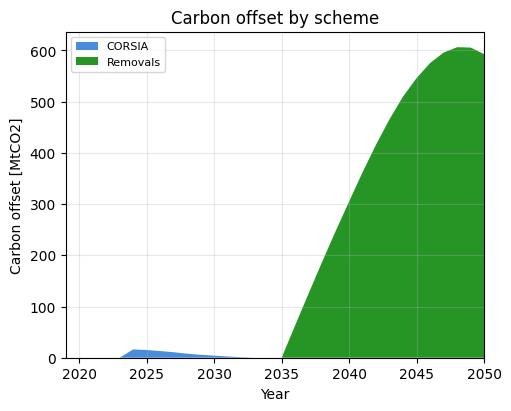

In [15]:
process.plot("carbon_offset_by_scheme", save=False)

The expense of each scheme is its quantity at its own price.

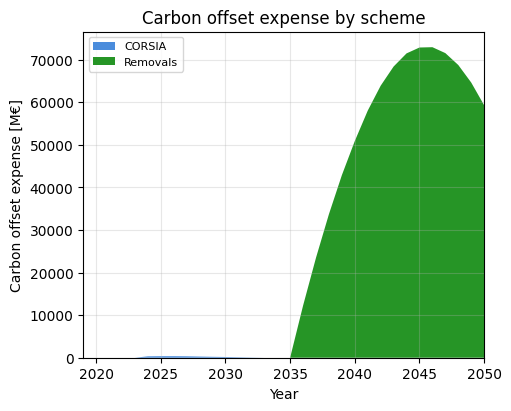

In [16]:
process.plot("carbon_offset_expense_by_scheme", save=False)

## Check that the decompositions are exact

Each set of sub-wedges sums to the wedge it splits. The residuals below are floating-point noise only.

In [17]:
years = range(process.parameters.prospection_start_year, process.parameters.end_year + 1)

cascade = {
    "demand": (
        "co2_emissions_last_historical_year_technology_baseline3",
        "co2_emissions_last_historical_year_technology",
    ),
    "efficiency": (
        "co2_emissions_last_historical_year_technology",
        "co2_emissions_including_aircraft_efficiency",
    ),
    "operations": ("co2_emissions_including_aircraft_efficiency", "co2_emissions_including_operations"),
    "loadfactor": ("co2_emissions_including_operations", "co2_emissions_including_load_factor"),
    "energy": ("co2_emissions_including_load_factor", "co2_emissions_including_energy"),
}


def wedge(lever):
    upper, lower = cascade[lever]
    return (vector[upper] - vector[lower]).loc[years]


def residual(lever, sub_wedges):
    return float((wedge(lever) - sub_wedges.loc[years].sum(axis=1)).abs().max())


print("efficiency per aircraft:", residual("efficiency", vector[efficiency_columns]))
print("energy per pathway:    ", residual("energy", vector[energy_columns]))
print("operations per concept:", residual("operations", vector[operations_columns]))
offset_residual = (vector["carbon_offset"] - vector[offset_columns].sum(axis=1)).loc[years]
print("offset per scheme:     ", float(offset_residual.abs().max()))
for lever in cascade:
    print(f"{lever} per market:".ljust(24), residual(lever, per_market.xs(lever, level="lever", axis=1)))

efficiency per aircraft: 1.2505552149377763e-12
energy per pathway:     5.755396159656812e-13
operations per concept: 2.842170943040401e-14
offset per scheme:      0.0
demand per market:       0.0
efficiency per market:   7.958078640513122e-13
operations per market:   6.536993168992922e-13
loadfactor per market:   5.115907697472721e-13
energy per market:       2.2737367544323206e-13


In [18]:
# Verify the outputs between .outputs.json and data/reference/outputs.json
from aeromaps.utils.functions import compare_json_files

files_are_different = compare_json_files(
    "./data/reference/outputs.json",
    "./data/outputs.json",
    rtol=0.0001,
    atol=0,
)

if files_are_different:
    raise ValueError("The outputs.json files are different.")

No differences found.


In [19]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())